# WETH/USDC Realistic Simulator

**Goal:** an end-to-end simulator of the Uniswap V3 5bp WETH/USDC pool whose retail outcomes match on-chain reality.

**Structure.** §1 and §2 show that the realistic simulator's *primitives* (price returns, retail order arrivals and sizes) match the empirical distributions where the Simple AMM Challenge defaults don't. §3 introduces the two-pool architecture. §4 calibrates the one free piece of that architecture — the V2 *normalizer pool* that represents the rest of the market — against the realized non-5bp retail impact curve. §5 validates the calibration against retail-only outcomes on the 5bp pool, which never feed into the fit. §6 reads the validation. §7 turns the retail-sample choice into a robustness dial (conservative ↔ aggressive). §8 recalibrates the normalizer to the *whole* current on-chain market — the competitor a new submission strategy is tested against. §9 runs a candidate strategy (the Guidestar volatile hook) against that normalizer.


In [23]:
import sys, os, importlib

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

# Reload helpers so re-running this cell picks up edits without a kernel restart.
import helpers
importlib.reload(helpers)
from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [24]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

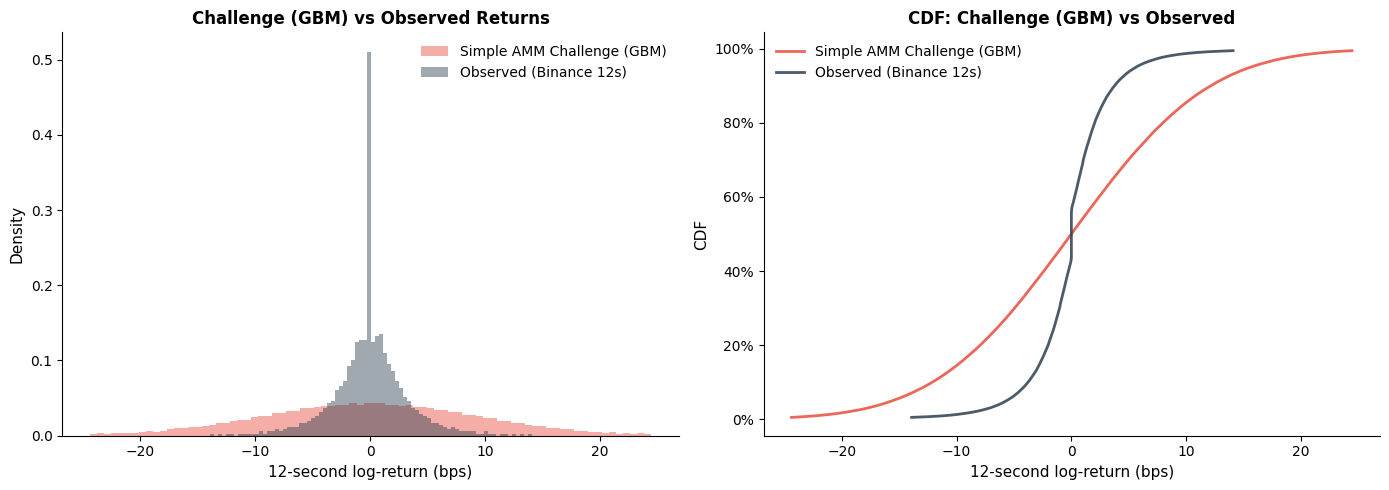

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

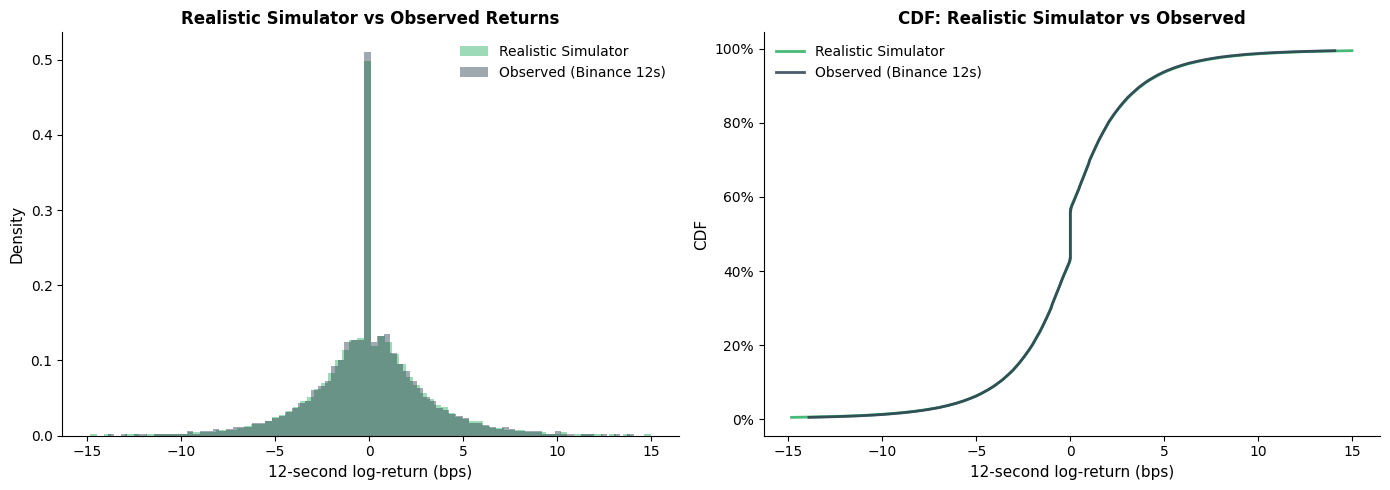

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

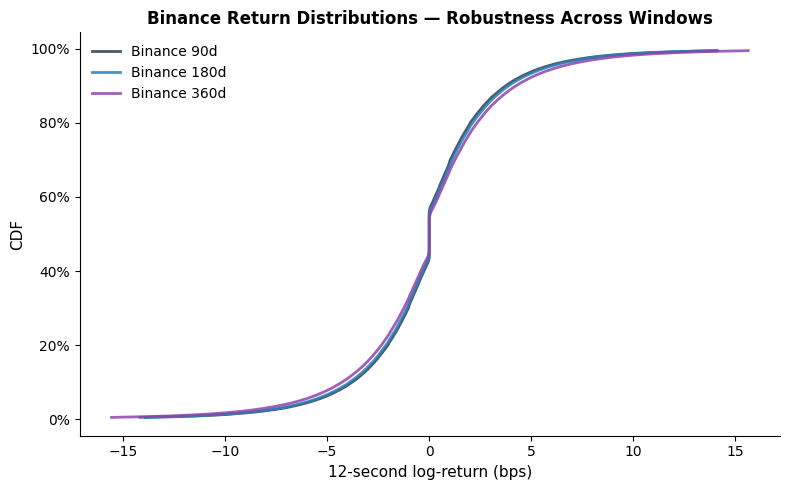

In [27]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ &#36;20, σ = 1.2). Real retail flow looks nothing like that. We now measure it on the **same strict-retail cohort used for calibration (§4) and validation (§5)** — transactions from a known end-user front-end: the **Uniswap first-party app** (web / mobile / extension, via the `core.swaps` surface tag) ∪ **MetaMask Swaps** (87.5 bps fee) — over the 30-day window 2026-04-21..05-20.

Our realistic simulator samples **USD order sizes directly** from this strict empirical parent-order distribution, at the observed strict arrival rate (**~0.46/block**: 98,676 parent orders / 216,000 blocks). The broad 19-router cohort (~0.66/block) is retained for robustness checks but is no longer the primary sample.

### Chart 2a: Arrival Rates

The realistic simulator's arrival rate (~0.46/block) is matched to the observed strict-retail rate by construction. The Challenge's fixed 0.8/block is calibrated to nothing in particular and overstates strict-retail arrivals by ~75%.

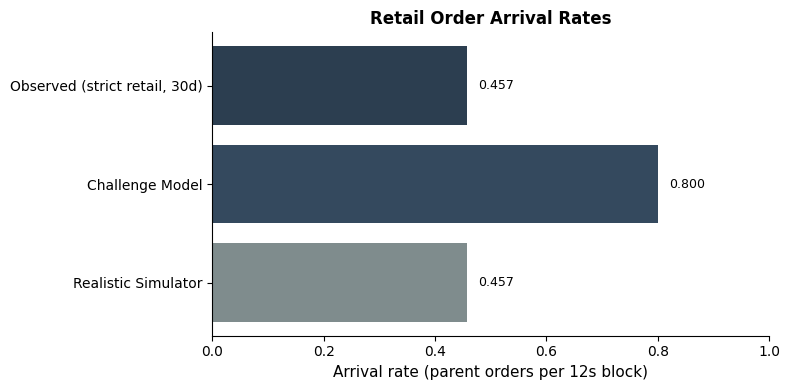

In [28]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [29]:
observed_retail = load_strict_retail_quantiles()
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around &#36;20 and completely misses the heavy right tail of real orders.

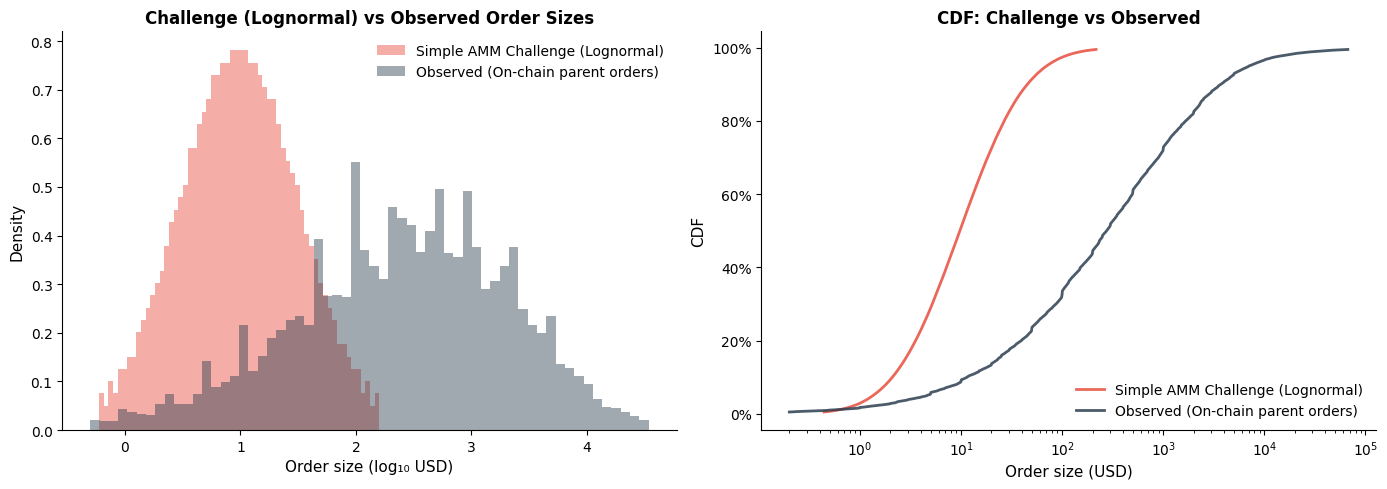

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed strict-retail parent-order distribution (the sim samples directly from it). Critically, the strict cohort's size tail tops out near **&#36;1.4M — no multi-million-dollar whale trades** — which is what fixes the LP-markout overshoot seen with the broad cohort (see §6).

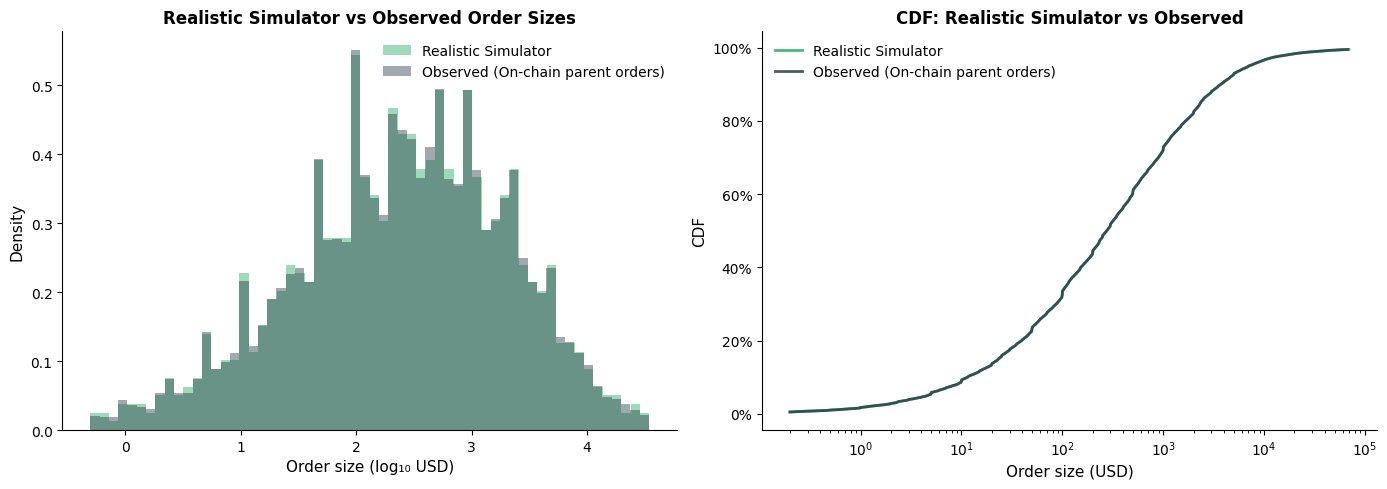

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Two-pool architecture

The simulator models the WETH/USDC market as two pools:

- **Submission pool.** The real Uniswap V3 5bp pool, **frozen** at its on-chain configuration: `fee = 5 bps`, `virtual_depth_y = &#36;212.16M` USDC. No free parameters. Arbitrageurs trade against it each step to pull its mid toward the prevailing fair price.
- **Normalizer pool.** A single hypothetical V2 (constant-product) pool that represents *everything else* — V4 1bp + 30bp, V3 30bp, V2, Curve, Balancer, etc. Two free parameters: spread **φ** (proportional fee) and depth **D** (USDC-side).

**The normalizer is held at fair, not arbed.** At the top of every step the normalizer's mid is re-synced directly to the current fair price at constant USDC depth `D` (`reserve_y = D`, `reserve_x = D/fair`). It therefore represents the *efficient* rest-of-market — always correctly priced the instant retail arrives — and **no arbitrage ever hits it**. (Previously the normalizer was a live pool dragged toward fair by a per-step arb; that left it slightly stale between arbs and made its price depend on arb timing. Snapping it to fair removes both artifacts.) Only the 5bp submission pool is arbitraged.

Each retail order is **split across both pools to equalize their marginal execution price** (the closed-form two-AMM optimal split in `OrderRouter.split_buy/sell_two_amms`) — not routed wholesale to a single venue. The deeper / cheaper pool simply receives the larger share. The normalizer's `(φ, D)` is the only thing we calibrate.

---
## Section 4: Calibrating the normalizer pool

**Target.** The empirical price-impact curve of **strictly-retail** transactions across **all non-5bp** WETH/USDC venues, referenced against the **prevailing fair price one 12s step before the trade** (the real-data analog of the simulator's "1 step before"). For each tx we measure:
- `size_usd` — total USD traded across the tx's non-5bp legs (any venue)
- `spread_bps` — `1e4 × (effective_price − fair_lag) × side / fair_lag`, where `fair_lag` is the fair price at or before 12s before the trade.

**Why all non-5bp venues (not just V3).** The normalizer is the competitor the held-out 5bp pool is validated against — and the 5bp pool competes against **every** other pool on the pair, not just the V3 ones. An earlier version of this sample was **V3-only**, which dropped the ~10% of non-5bp flow on V4 / Fluid / Balancer / Curve / … and biased the fit. Because the calibration target is the lagged Binance mid (below), it needs only the routed order amounts — not any per-pool mid — so we build it straight from `markout_prod` across all venues. This is the **same build as the §8 full-market sample, just excluding the 5bp pool**: §4 = all venues *minus* 5bp (5bp is the submission pool being validated), §8 = all venues *including* it.

**Why a strict-retail filter.** The normalizer pool exists to be a realistic *retail* competitor to the submission pool — the question it answers is how retail order routing reacts to changes in the new pool. So it is calibrated to flow that is unambiguously human retail on a known front-end, not the broad router-level superset (which mixes in MM execution, arb bots, and aggregator flow). The cohort is the **union of two front-end sources**:
- **Uniswap first-party front-end** (web app + mobile wallet + extension) — from `uniswap-labs.core.swaps`, which materializes the off-chain `x-request-source` surface tag and the tx hash. There is *no* on-chain marker for interface flow (Uniswap dropped the web/mobile swap fee at UNIfication 2025-12-27, and web/mobile build byte-identical calldata), so this internal surface attribution, joined by tx hash, is the only clean signal. It is the dominant retail source.
- **MetaMask Swaps** — txs that paid the **87.5 bps** convenience fee to `0xf326e4…f1915` (Etherscan "MetaMask: DS Proxy"; ~87.9 bps empirically).

The two surfaces are disjoint (zero tx overlap). A 25 bps collector `0xcd6b98…` that initially looked like a Uniswap interface fee turned out to be **Rabby Wallet**, not Uniswap, and is excluded.

**Why lagged fair (not pool mid, not contemporaneous fair).** This matches the normalizer's role in §3: retail trades against a pool sitting at the prevailing fair, so we calibrate impact *relative to fair*. We use a **pre-trade** fair (one 12s step stale) so the reference cannot have been moved by the trade's own impact. The cost is noise — each trade's spread also carries ~12s of price drift — so the USD-weighted **Huber** loss (Plan B) is the robust default. The all-venue sample (from `markout_prod`) carries the contemporaneous-fair spread as a diagnostic, but **no per-pool mid** — so pool-mid-based sandwich detection lives on the V3 subset only (Chart 3b).

**Fair-price source.** The Binance book table only covers 2023-04..2025-11, so the fair series is reconstructed from `markout_prod.benchmark` over all WETH/USDC swaps (last observation per 12s bucket, forward-filled), and each trade reads the bucket immediately preceding its own. See `analysis/weth_usdc_90d/sql/non5bp_allvenue_impact_30d.sql`.

**Universe & window.** All non-5bp WETH/USDC swap legs across every venue, aggregated per tx, restricted to the strict-retail cohort, over a **30-day window (2026-04-21..2026-05-20)**: **~92K transactions**. The retail trades span up to ~&#36;379K (median ~&#36;430; **none ≥ &#36;1M** — no whales; in fact the biggest retail trades all route at least partly through the deep 5bp pool, so excluding it caps the non-5bp tail at ~&#36;379K). The range is wide enough that the impact slope is clearly visible, so **D is well-identified** — Plan A (L2) and Plan B (Huber) independently agree on D ≈ &#36;73–79M.

**Model.** A V2 constant-product pool with fee φ and depth D has retail-side spread

$$\text{spread} = \frac{\varphi + (1-\varphi)\,S/D}{1-\varphi}\,.$$

**Loss.** USD-weighted Huber on residual spread (`scripts/calibration/fit_impact_curve_pool_mid.py`, Plan B; δ = 90th percentile of |residual| under the USD-weighted-L2 Plan A). We default to Plan B below: **φ = 3.68 bps, D = &#36;73.4M** (vs the old V3-only fit's φ = 2.18 bps, D = &#36;63.9M — the higher floor reflects the higher-fee non-V3 tiers now included).

In [32]:
fit = load_impact_curve_fit()
phi_b   = fit['plan_b']['phi']
depth_b = fit['plan_b']['depth_usdc']
print(f"Plan B fit")
print(f"  φ      = {phi_b*1e4:.3f} bps")
print(f"  depth  = ${depth_b/1e6:,.1f}M USDC")
print(f"  n_txs  = {fit['n_txs']:,}")
print(f"  window = {fit['window']}")


Plan B fit
  φ      = 3.675 bps
  depth  = $73.4M USDC
  n_txs  = 91,655
  window = 2026-04-21..2026-05-20


### Chart 3a: Empirical impact curve + V2 fit (all non-5bp venues)

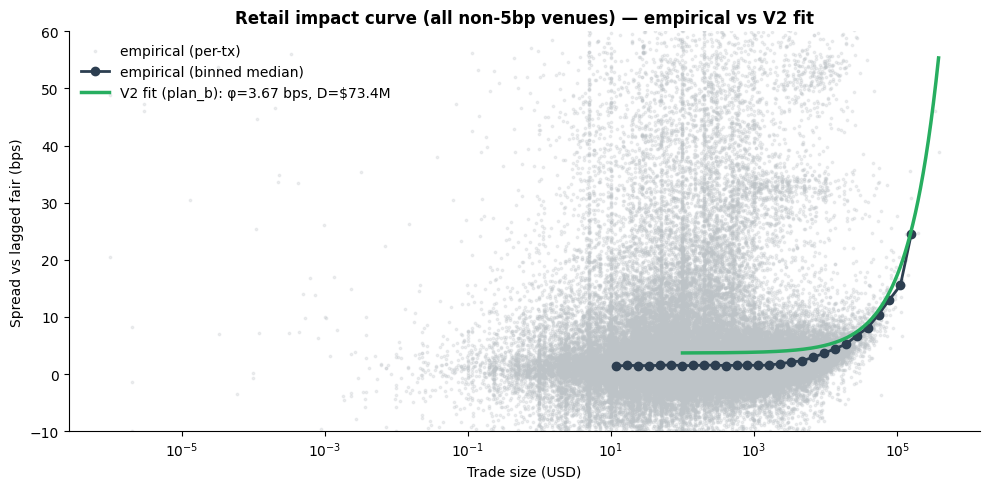

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b')
plt.tight_layout()
plt.show()


### Chart 3a (by venue): what is the elevated band above the V3 mass?

Chart 3a shows a diffuse band of points sitting ~25–35 bps **above** the V3 calibration mass (which hugs ~2 bps). Colouring each tx by its dominant venue + version — with the per-venue median (◆) — shows the band is **fixed-fee venues, not price impact.** Three findings, each with the pool's fee read **on-chain**:

**1 — A flat ~28–33 bps fee-tier band: the non-V3 venues the old V3-only sample omitted.** A fixed-fee pool sits at ~its fee regardless of trade size (flat), unlike an impact curve (rising):

| Venue (verified) | Prominent pool(s) | Fee (on-chain) | Median spread | venue n |
|---|---|---|---|---|
| **Uniswap V2** | `0xb4e16d…` — the USDC/WETH pair (all V2 flow) | 30 bp (V2 fixed) | ~25 bps, flat | 5,007 |
| **Curve** | `0x70c517…` cryptoswap `fee()`=33bp; `0x89c971…` StableSwap-NG `fee()`=28bp | 28–33 bp | ~32 bps, flat | 210 |
| **Balancer V3** | `0xe0af30…` Gyroscope E-CLP, swap fee 28 bp | 28 bp | ~32 bps, flat | 282 |

The band totals **5,499 txs = 6.0% of trades, 3.8% of USD**, and **by count is overwhelmingly the Uniswap V2 30bp pair** (`0xb4e16d…`); Curve + Balancer add a thin higher-fee fringe. Every one of these spreads is **flat across trade size** (e.g. Curve `0x70c517` reads 32.9 → 33.0 → 32.1 bps from &#36;1K to &#36;250K) — the fingerprint of a swap fee, not mechanical impact.

**2 — Uniswap V4 is mostly *low*-fee, so it joins the cheap mass, not the band.** All V4 swaps collapse to the PoolManager singleton `0x0000…4444` (fee tiers live in the poolId, not the address); its WETH/USDC flow concentrates in the 1bp / 5bp / dynamic-fee-hook pools (per-pool realized spread 1–6 bps, rising with size like impact). V4 is **17.8% of txs at a 3.8 bps median** — it sits *inside* the calibration mass. Only a thin 30bp V4 pool throws off a few high-spread points (the ~35 bps median over its 78 txs is MEV, not a fee tier).

**3 — The very top of the cloud (~40–55 bps, red) is the Uniswap V3 1bp pool's wide-vs-fair tail.** A 1bp fee can't produce 40+ bps, so these are execution-vs-lagged-fair outliers (1,479 txs). Cross-checked against the V3 sample: **~⅓ (473) are genuine sandwich/MEV victims** — the Chart 3b red cluster — and **~⅔ are 12s-lagged-fair drift noise** (the trade filled at ~the pool mid, which tracked fair, but the *stale* fair reference had moved). Both were already in the V3-only chart; Chart 3b below isolates the true-sandwich third.

**Does it move the fit? Barely — and correctly.** The fee-tier band is real cost retail pays on those venues, but it is 6% of trades / 3.8% of USD; the USD-weighted Huber fit is anchored by the 1bp-pool + V4 low-fee mass (94% of flow, ~2 bps). The band lifts the blended floor only slightly — which is exactly the φ = 2.18 → 3.68 bps move from adding the non-V3 venues.

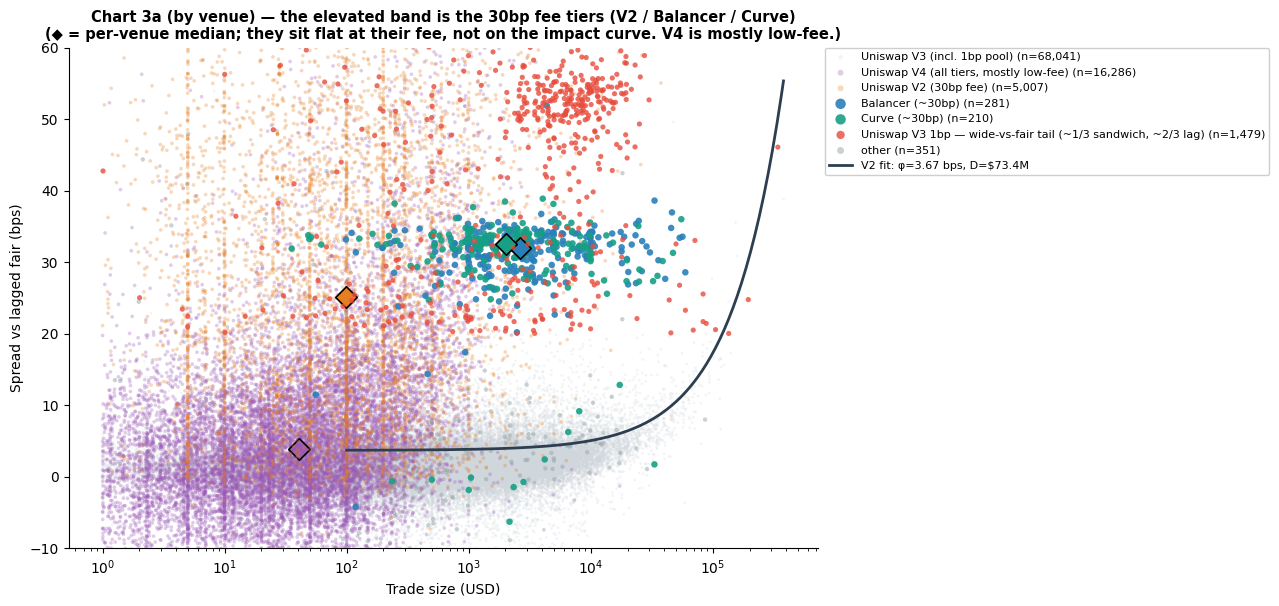

In [34]:
fig, ax = plt.subplots(figsize=(14, 6.5))
plot_impact_curve_by_venue(ax=ax)
plt.show()

### Chart 3a (by router): Uniswap FE vs MetaMask

The same per-order impact cloud, coloured by the order's **router** (a per-`tx_hash` property): Uniswap first-party FE (n=86,183) vs the MetaMask 87.5bps-fee cohort (n=5,472), with the **MetaMask→Curve/Balancer** subset drawn separately. Counts by venue: Balancer 265 MetaMask / 16 Uniswap; Curve 188 / 22; Uniswap-FE flow concentrates in V3 (64,347) and V4 (15,565). Overall median lagged-fair spread: Uniswap 1.68 bps, MetaMask 1.74 bps. The 39 non-MetaMask Curve/Balancer orders are UniswapX (`routing=uniswap_x_v2`) fills whose WETH/USDC leg a filler settled on Curve/Balancer (`analysis/weth_usdc_90d/uniswapx_on_balancer_curve_txs.csv`).

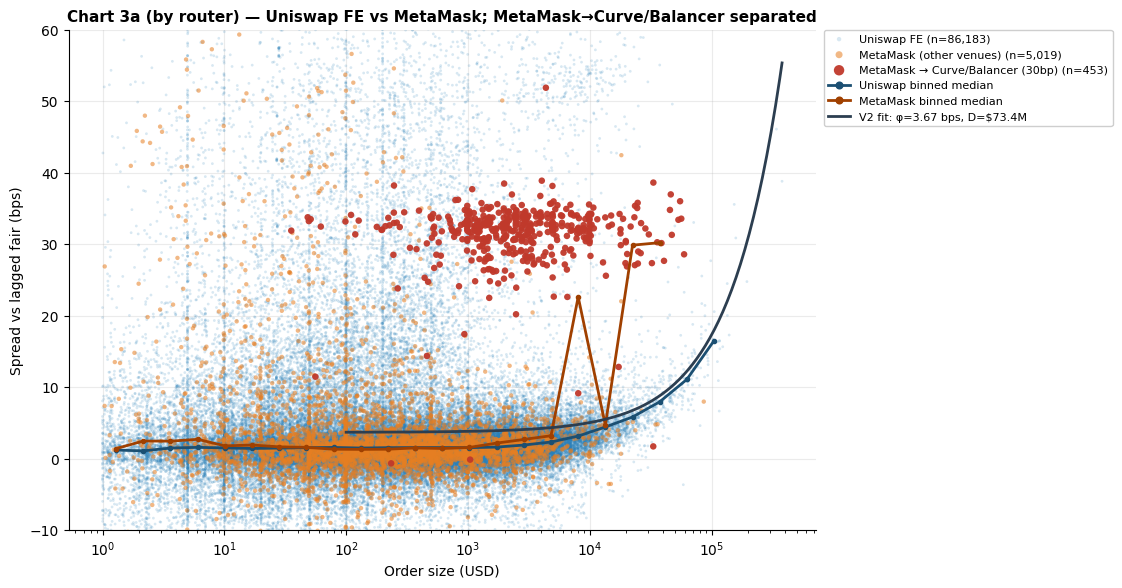

In [35]:
fig, ax = plt.subplots(figsize=(13, 6.5))
plot_impact_curve_by_router(ax=ax)
plt.show()

**Sandwiches — a V3-subset diagnostic (Chart 3b).** The all-venue calibration sample above comes from `markout_prod`, which carries no per-pool pre-trade mid, so sandwich victims can't be color-coded on it. On the **V3 subset** — where each pool's `sqrtPrice` gives a pre-trade mid — the signature is visible (red below):

a trade fills against a pool whose **pre-trade mid was already pushed off fair** — the on-chain sandwich / transient-MEV-excursion signature. Verified on same-block traces: a *separate* frontrun tx earlier in the block pushes the pool 10–68% off fair, the retail trade fills at that pushed price, and a backrun restores the pool within the same block. (This is why these trades look cheap vs the pool's own pre-trade mid — `pool_mid_pre` = the frontrun's price — but expensive vs an external CEX fair.)

**Rule** — applied to every trade in the V3 sample (not just the visible cluster). A trade is flagged *sandwiched* when:

```
|pool_mid_pre_blended / fair_price_blended − 1| > 0.5%   AND   |observed_spread_pool_bps| < 20 bps
```

i.e. the pool's pre-trade mid sat more than 0.5% (50 bps) from the contemporaneous fair, while the fill itself executed within 20 bps of that pushed mid — a *victim* of the push, not a trade that moved the pool with its own size. This flags **473 of ~70K** V3 trades (mostly the 1bp pool `0xe0554a…`, largely memecoin multi-hop routes that touch WETH/USDC as a hop).

These are **MEV slippage, not the pool's mechanical impact**, which is why they sit above the V2 fit. The USD-weighted Huber loss down-weights them in either sample, so the fitted `(φ, D)` is robust to them whether or not they're flagged.

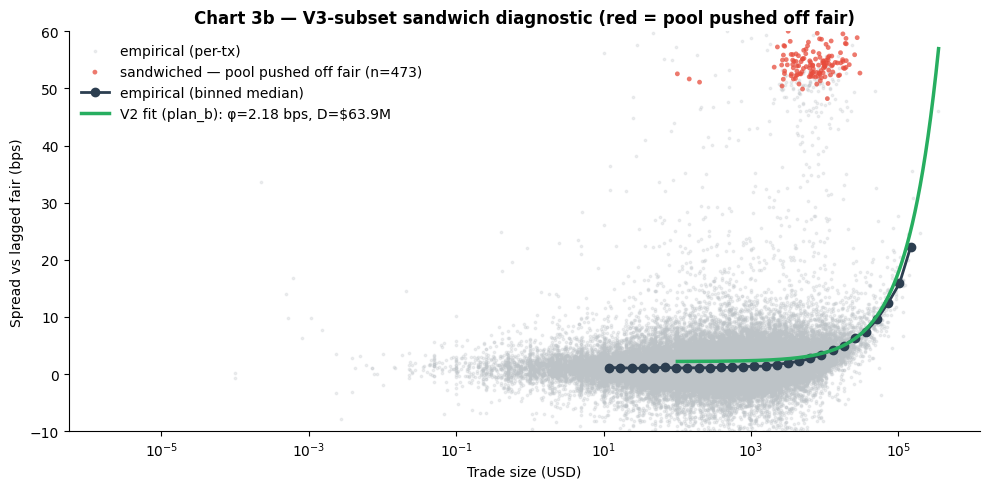

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b',
                      sample=load_impact_curve_sample_v3(),
                      fit=load_impact_curve_fit_v3(),
                      title="Chart 3b — V3-subset sandwich diagnostic (red = pool pushed off fair)")
plt.tight_layout()
plt.show()

### All-venue sandwich census — the heuristic table (V4 / Pancake / Curve / …)

Chart 3b's pool-mid detector only sees **V3** pools (it needs each pool's `sqrtPrice`). To check **non-V3** venues we use the heuristic sandwich table `uniswap-allium.ethereum.dex_sandwich_trades` — the BigQuery recreation of Dune's [`dex.sandwiches`](https://docs.dune.com/data-catalog/curated/dex-trades/evm/dex-sandwiches) — which records the attacker `front`/`back` legs; a **victim** is any swap on the same pool+block sitting between them. Reconstructed for WETH/USDC over the 30d window (`sql/sandwich_victims_allvenue_30d.sql`):

**The V3-only view missed half the sandwiches.** All-venue WETH/USDC sandwich attacks split almost evenly across **Uniswap V4 (~2,150)**, **Uniswap V3 (~1,720)** and **PancakeSwap V3 (~1,600)**, with a thin tail on Solidly / Curve / V2 / Balancer / DODO / Fluid. By *dollars* sandwiched, V3 dominates (~&#36;15.7M — larger trades) while V4 / Pancake are many small trades.

**In our strict-retail calibration sample, 1.47% of trades are sandwich victims, and the non-V3 share is real:**
- **Uniswap V4 — 489 of 16,286 (3.0%), median +98 bps.** These ARE the high-spread V4 points in Chart 3a: the heuristic confirms they are *sandwiches*, not a fee tier (V4's clean flow medians ~3.5 bps).
- **V3 1bp wide-vs-fair tail — 790 of 1,479 (53%) confirmed, median +76 bps.** Our conservative pool-mid rule (Chart 3b) flagged ~⅓; **465 of those 473 (98%) are corroborated here**, so the rule was precise but under-counted.
- **Uniswap V2 / Balancer / Curve — ≤0.04% sandwiched.** The 30 bp band from Chart 3a is **fee, not MEV** — confirmed independently.

**Implication for the calibration.** Sandwich victims are a small, identifiable tail (1.5% of trades) concentrated on V4 and the V3 1bp pool; the USD-weighted Huber fit already down-weights them, and the fee-tier band venues are clean. So the all-venue normalizer (φ = 3.68 bps, D = &#36;73.4M) is **not contaminated by MEV** — every wide-spread region is now accounted for (fee tiers + a quantified sandwich tail), not mysterious.

All-venue WETH/USDC sandwich victims in the window, by protocol:


,protocol,victims,usd_m
0,uniswap_v4,2150,0.41
1,uniswap_v3,1718,15.69
2,pancakeswap_v3,1600,0.52
3,solidly,22,0.00
4,curve_v2,15,0.06
5,uniswap_v2,9,0.00
6,balancer_v3,5,0.04
7,balancer_v1,4,0.00
8,curve_v1,4,0.00
9,dodo_v2,1,0.00


Of our strict-retail calibration sample, sandwich victims by venue:


,venue,n,victims,victim_pct,med_spread_victim_bps
0,Uniswap V3 1bp — wide-vs-fair tail (~1/3 sandw...,1479,790,53.41,76.4
1,"Uniswap V4 (all tiers, mostly low-fee)",16286,489,3.00,97.8
2,Uniswap V3 (incl. 1bp pool),68041,70,0.10,3.5
3,Uniswap V2 (30bp fee),5007,2,0.04,14.0
4,Balancer (~30bp),281,0,0.00,NaN
5,Curve (~30bp),210,0,0.00,NaN
6,other,351,0,0.00,NaN


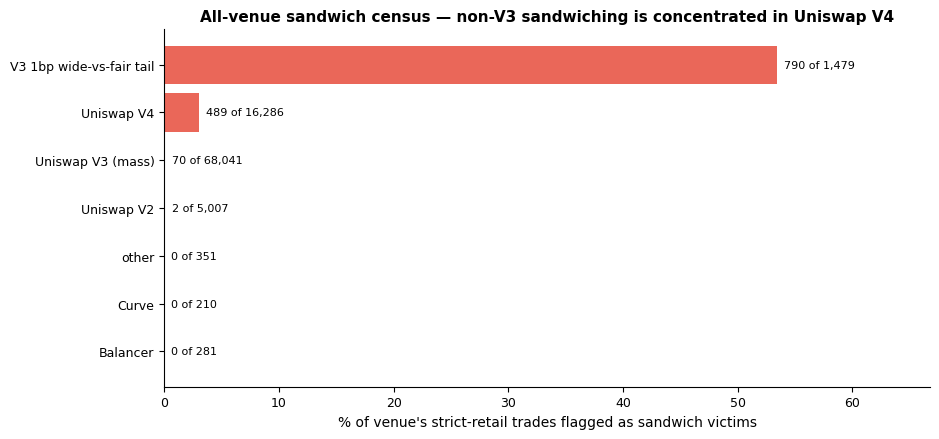

In [37]:
by_protocol, by_sample_venue = sandwich_census()
print('All-venue WETH/USDC sandwich victims in the window, by protocol:')
display(by_protocol)
print('Of our strict-retail calibration sample, sandwich victims by venue:')
display(by_sample_venue)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
plot_sandwich_census(ax=ax)
plt.tight_layout()
plt.show()

---
## Section 5: Held-out retail validation

We now run the simulator with the calibrated normalizer and the frozen 5bp submission pool, and compare three **retail-only** outcomes against on-chain reality. Crucially, none of these metrics fed into the fit — they are genuinely held out.

We focus on retail because the arb side carries no free parameters: only the 5bp submission pool is arbitraged (the normalizer is held at fair by construction, §3), and that arb is closed-form and deterministic. The retail-side metrics carry the signal about whether the normalizer pool's `(φ, D)` is correct.

**Metrics**
1. **Retail volume share at 5bp** = `retail_vol_5bp / retail_vol_total`.
2. **Retail fee share at 5bp**    = `retail_fees_5bp / retail_fees_total`.
3. **USD-weighted retail markout_15s distribution** at the 5bp pool. Convention: `markout_15s` for LP profitability (15 seconds is the standard horizon); USD-weighted percentiles emphasize the large trades that drive LP P&L.

**Real numbers** are pulled from `dex_trades` (volume + fees) and `markout_prod` (per-swap markouts) over the same 30-day window, on the **same strict-retail cohort** (Uniswap first-party FE ∪ MetaMask) used for calibration and the size distribution — so sim and real describe the identical population (the symmetry §7 argues for). See `sql/retail_5bp_share_strict_30d.sql` and `sql/markout_5bp_pool_strict_30d.sql`. (The broad 19-router builders are kept for robustness.)

**Sim numbers** are produced by `scripts/calibration/validate_pool_mid.py` with five seeds × 5,000 steps. Per-trade sim markouts use the next-block `fair_price` (~12s — closest available proxy for the 15s real reference).

In [38]:
validation = load_validation()
get_validation_summary_table()


,Metric,Real (on-chain),Simulator
0,Retail volume share @5bp,45.89%,55.09% ± 1.02pp
1,Retail fee share @5bp,17.36%,62.53% ± 0.97pp
2,Retail markout_15s — USD-w mean,+9.71 bps,+5.02 bps
3,Normalizer φ,—,3.67 bps
4,Normalizer depth,—,$73.4M
5,Submission pool fee,5.00 bps (frozen),5.00 bps (frozen)
6,Submission pool depth,$212.2M (frozen),$212.2M (frozen)


### Chart 5a: Retail volume / fee share at 5bp pool


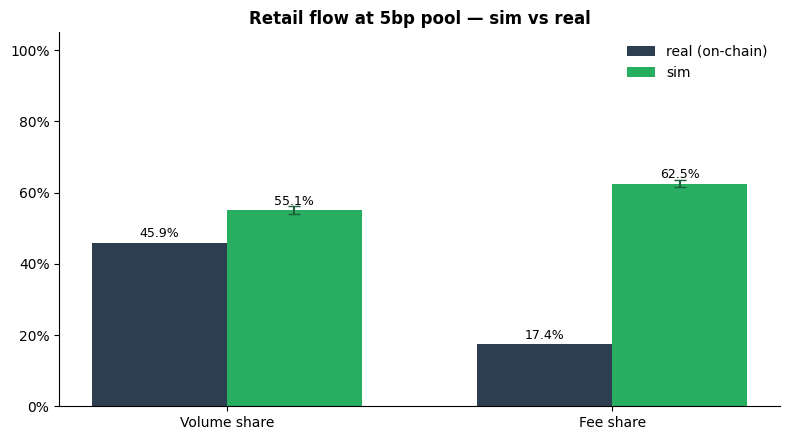

In [39]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_retail_share_bars(ax=ax)
plt.tight_layout()
plt.show()


### Chart 5b: Retail markout_15s on 5bp pool — USD-weighted


/Users/xinwan/Github/amm-gym/presentation/helpers.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


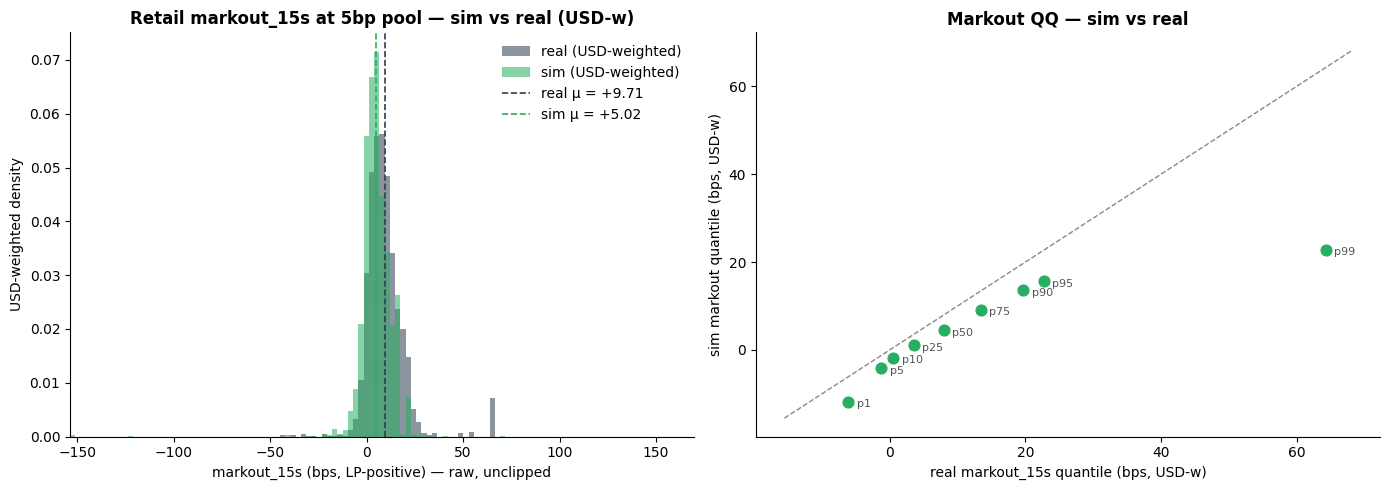

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_retail_markout_overlay(ax=ax1)
plot_retail_markout_qq(ax=ax2)
plt.tight_layout()
plt.show()


---
## Section 6: Reading the validation

**Caveat on the real-world numbers.** This is the *cleaned, strict-retail* validation. An earlier version included two Wintermute MM contracts in the retail-router list; with them in, retail volume share at 5bp looked like 78% and markout like −3 bps, and the sim spuriously "matched." After the router cleanup — and a further shift of **all three samples (size distribution §2, calibration §4, validation §5) onto a single strict end-user front-end cohort** (Uniswap first-party FE via `core.swaps` ∪ MetaMask 87.5bps fee, 30d) — sim and real describe the *identical* population. (The broad 19-router method is kept for robustness.)

**How the model is specified now.**
1. **Normalizer held at fair, not arbed (§3)** — snapped to current-step fair at constant depth `D`; no arb touches it.
2. **Calibrated to lagged pre-trade fair on strict-retail *all-non-5bp-venue* flow (§4)** — φ = 3.68 bps, D = &#36;73.4M, well-identified. (This is the corrected competitor; the earlier V3-only fit was φ = 2.18 bps, D = &#36;63.9M.)
3. **Size distribution, arrival rate, buy share, and validation targets all on the same strict cohort** — arrival ~0.46/block, buy share 0.46, size tail topping out near &#36;379K (no whales).

**Markout — matched, and stable under the correction.** This was the headline gap. Strict real USD-weighted retail markout_15s is **+9.7 bps**; the sim shows **+5.0 bps** (Δ −4.7 pp), essentially unchanged from the V3-only normalizer's +5.3 bps — the normalizer's φ has little leverage on the 5bp pool's *own* markout, which is driven by the size distribution and the 5bp impact. (Down from +58 bps under the old broad size distribution: the strict tail produces **0 sim trades ≥ &#36;1M**, vs the broad cohort's &#36;5M whales that marked out ~+250 bps each.) The sim slightly *undershoots*, consistent with real strict-retail being marginally more profitable to the LP than the uninformed sim flow.

**Volume share — now overshoots, and that is informative.** Strict real retail routes ~45.9% of WETH/USDC flow to the 5bp pool; the sim routes **~55.1%** (Δ +9.2 pp), up from ~48.9% under the V3-only normalizer. The *correct* all-venue competitor has a higher fee floor (φ ≈ 3.7 vs 2.2 bps), which makes the 5bp pool look relatively cheaper, so the sim sends it more flow. The V3-only fit happened to match volume share better (Δ ~+3 pp) but it was the **wrong competitor** — it dropped ~10% of non-5bp flow. The overshoot is the real lesson: a single blended-φ V2 can't simultaneously serve **volume routing** (which keys off the cheapest *marginal* venue — the 1bp V3 pool) and **impact/markout** (which keys off the volume-blended curve). The blended fit is right for markout and overstates the competitor's price for routing.

**Fee share — still fails large.** Strict real retail pays only ~17% of its WETH/USDC fees at the 5bp pool; the sim produces **~63%** (down from ~69%, but still inverted). A single V2 normalizer at φ ≈ 3.7 bps is *cheaper* than the 5bp pool, while in reality the rest-of-market fee revenue is dominated by high tiers (V4 / V3 30bp, Curve, …) and is *more* expensive than 5bp. One φ can't reproduce that mix.

**Takeaway.** With the corrected all-venue normalizer the simulator still matches real retail on markout (within ~5 bps). Volume share now overshoots by ~9 pp and fee share remains structurally off — both for the same reason: collapsing a heterogeneous multi-tier market into one blended-φ V2 pool. A **multi-tier normalizer** (a few pools at the real fee tiers sharing the order flow) is the single change that would fix both, and is the higher-leverage next step over any further cohort filtering.

---
## Section 7: Retail-sample robustness

All three uses of real retail data — the size distribution (§2), the calibration (§4), and the validation (§5) — now sit on **one cohort**: transactions from a known end-user front-end (Uniswap first-party app via the `core.swaps` surface tag ∪ MetaMask Swaps' 87.5 bps fee). Calibrating, sizing, and validating on the *same* population is what makes the comparison apples-to-apples. (An earlier per-transaction audit confirmed the broad 19-router cohort mixes in MM / whale / arb flow. The size distribution is the use most sensitive to that contamination — it's why the strict shift collapsed the sim markout from +58 to +5 bps — while the impact-curve calibration is the least sensitive, since AMM mechanics don't depend on trader identity.)

**The catch: the strict cohort is a _subset_ of true retail.** It captures only two front-ends, so it almost certainly **understates the arrival rate**, and its size tail (capped ~&#36;1.4M) is thinner than the broad cohort's (~&#36;7M) — we likely **understate large-order frequency** too. The true distribution is unknown, and chasing it is a rabbit hole.

So rather than pick a single "best" sample, treat the retail assumption as a **dial**. We anchor on the strict cohort (conservative) and the broad 19-router cohort (aggressive) and interpolate the arrival rate and order-size quantiles between them. The sweep below shows how the validation metrics move across that range; the slider lets you set the assumption yourself and re-run the sim.

**Takeaway.** Volume share and especially markout are sensitive to the retail-size assumption — markout ranges from ~+5 bps (conservative) to ~+80 bps (aggressive) as the size tail fattens — so read the sim's absolute markout as a *band*, not a point. **Fee share stays ~68–75% across the whole range**: that's a structural normalizer-fee-mix gap, not a sampling artifact, and it's the one conclusion that holds regardless of where you set the dial.

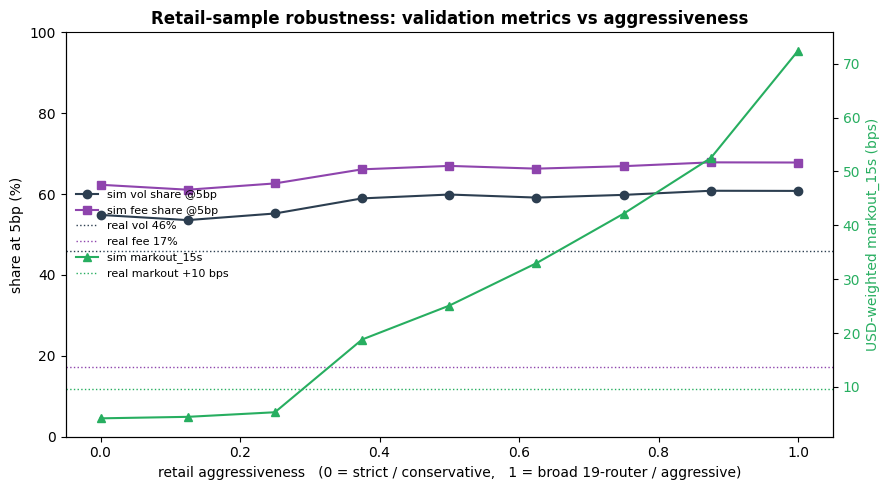

In [41]:
# Sweep the retail assumption from strict/conservative (0) to broad/aggressive (1).
# Re-runs the validation sim at each anchor; ~10-15s.
fig, ax = plt.subplots(figsize=(9, 5))
plot_retail_robustness_sweep(ax=ax)
plt.tight_layout()
plt.show()

In [42]:
# Interactive (JupyterLab): drag to set how aggressive vs conservative the retail
# assumption is (arrival rate + order-size tail); the sim re-runs and reports the
# validation metrics. Static export shows the conservative (strict) end.
retail_robustness_slider()

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='aggressiveness', layout=Lay…

---
## Section 8: The full-market normalizer (for testing new strategies)

§4–§6 calibrated and *validated* the methodology by holding the 5bp pool out as the submission pool and letting the normalizer stand in for "everything else" — so the 5bp pool was deliberately **excluded** from the normalizer.

Testing a **new** mechanism flips this: **the new mechanism becomes the submission pool, and the 5bp pool is no longer special — it rejoins the market the new pool competes against.** So the normalizer must represent **all pools currently on-chain on the pair, the 5bp pool included.** We recalibrate it exactly as in §4 (strict-retail cohort, spread vs the lagged Binance mid, USD-weighted Huber V2 fit), but over the *whole* current WETH/USDC market.

Because the calibration references the **lagged Binance mid** (not each pool's own pre-trade mid), it needs only the **routed order amounts**, so it pulls straight from `markout_prod` across **every venue** (Uniswap V3 + V4 + V2, Fluid, Swaap, Pancake, Balancer, Curve, …). **§4 now uses this same all-venue build**, so §4 and §8 differ only by whether the 5bp pool is in the normalizer — §4 excludes it (5bp is the pool being validated), §8 includes it. (The only flow still outside the sample is whatever `markout_prod` doesn't track.)

The result is a deeper, higher-floor normalizer than the non-5bp one — it now contains the deep 5bp pool plus the full venue mix:

In [43]:
fm = load_allpools_impact_fit()
nb_fit = load_impact_curve_fit()
print("Full-market normalizer  (all venues, 5bp included) — Plan B (USD-w Huber):")
print(f"  φ        = {fm['plan_b']['phi']*1e4:.3f} bps")
print(f"  depth    = ${fm['plan_b']['depth_usdc']/1e6:,.1f}M USDC")
print(f"  n_txs    = {fm['n_txs']:,}")
print(f"  universe = {fm['universe']}")
print()
print(f"vs §4 non-5bp normalizer:  φ = {nb_fit['plan_b']['phi']*1e4:.3f} bps,  depth = ${nb_fit['plan_b']['depth_usdc']/1e6:,.1f}M")

Full-market normalizer  (all venues, 5bp included) — Plan B (USD-w Huber):
  φ        = 4.653 bps
  depth    = $275.1M USDC
  n_txs    = 97,900
  universe = ALL WETH/USDC venues (Uniswap V3+V4+V2, Fluid, Swaap, Pancake, Balancer, Curve, ...) via markout_prod

vs §4 non-5bp normalizer:  φ = 3.675 bps,  depth = $73.4M


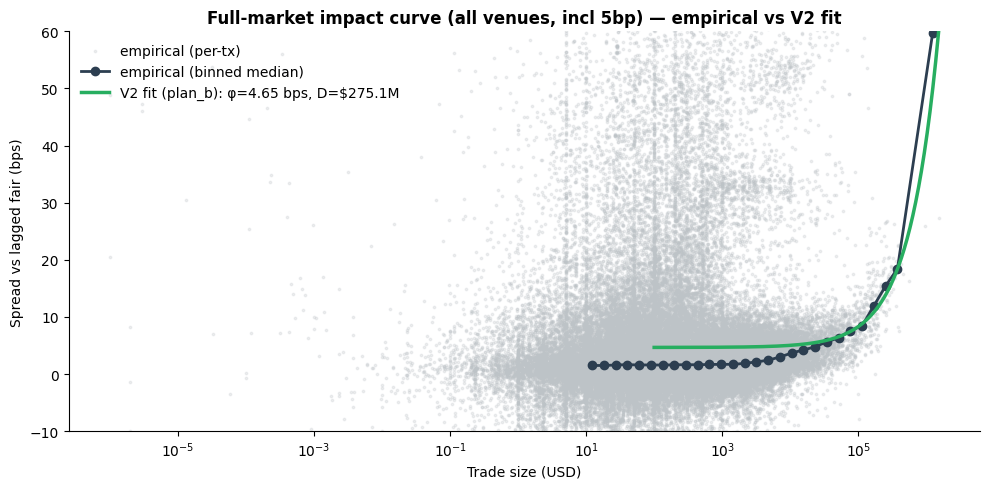

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax,
                      sample=load_allpools_impact_sample(),
                      fit=load_allpools_impact_fit(),
                      title="Full-market impact curve (all venues, incl 5bp) — empirical vs V2 fit")
plt.tight_layout()
plt.show()

**This (φ, D) is the competitor a new strategy is tested against:** plug the candidate mechanism in as the submission pool, use this full-market pool as the normalizer, and read its LP markout / edge / volume share — exactly the §5 setup, but with the new mechanism (not the 5bp pool) in the submission slot.

---
## Section 9: Testing a new strategy (Guidestar volatile)

§8 calibrated the full-market normalizer — the competitor a *new* submission strategy faces. This section runs a candidate strategy as the submission pool against that normalizer.

**Candidate.** The Uniswap **Guidestar volatile-pair hook** (`Guidestar4Volatile`), ported to the simulator's `before_swap` strategy interface (`arena_eval/exact_simple_amm/guidestar_volatile.py`; the port is checked against the contract's invariants in `tests/test_guidestar_volatile.py`). It sets separate buy/sell fees, each with a *permanent* and a *transitory* component. At the first swap of each block it reads the pool's price move since the previous block and updates the components: the moved side's permanent component increases (capped by `maxPermGrowth`); the opposite side's total fee is set to ≈ the price impact via its transitory component; both then decay over subsequent blocks (transitory linearly at rate `transDecline`, permanent exponentially at rate `k`) toward a floor of `2·feeInit`. Later swaps in the same block take a sandwich-protection floor.

Parameters are the **mainnet deployment defaults** (`guidestar-hooks/script/DeployGuidestar4.s.sol::defaultHookParams`): `feeInit` = 3.5 bps/side, `alpha` = 9000, `maxPermGrowth` = 16, `transDecline` = 0.10/block, `k` = 0.99/block, `maxPriceImprovement` = 10 bps.

The chart below drives the strategy through a scripted price path (one step = one block) and shows the resulting fees.

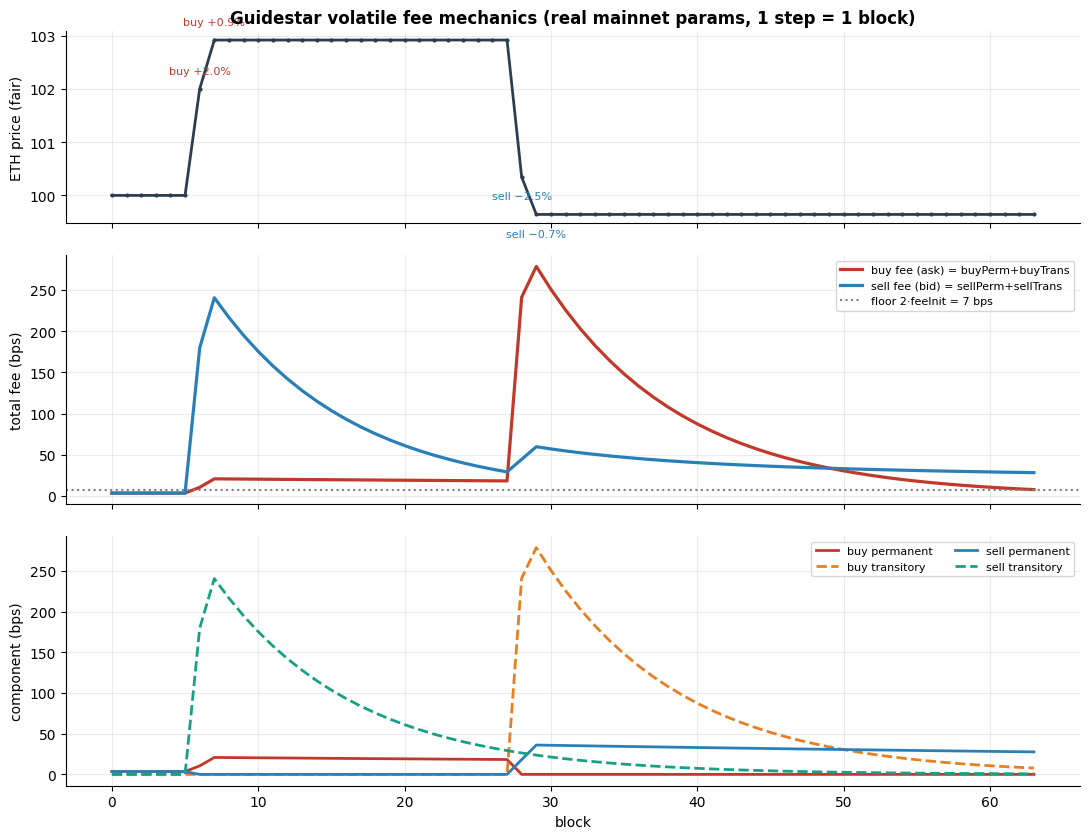

In [45]:
fig = plot_guidestar_dynamics()
plt.show()

**Backtest setup.** The candidate runs as the submission pool against the §8 full-market normalizer (φ = 4.65 bps, D = &#36;275M, held at fair). A new pool is taken to be shallow: depths of **&#36;1M** (primary) and **&#36;0.5M**. Two fixed-fee baselines at the same depth: **flat 3.5 bps** (= Guidestar's `feeInit`, i.e. the same floor with no dynamic component) and **flat 5 bps**. **Paired seeds**: identical fair path and retail arrival stream per seed — only the submission fee policy differs, so the routing split differs.

Metric: **15s-forward LP markout** — for each swap on the submission pool (retail + arb), the executed price marked against the fair price 15 s later, in dollars. 16 seeds × 5000 steps. Results are computed offline by `scripts/calibration/guidestar_backtest.py` and cached; the cells below load and plot the cache.

In [46]:
import pandas as pd
_c = load_guidestar_backtest()
_rows = [{'depth': f'${d/1e6:.1f}M', 'pool': nm.split(" (")[0],
          'final cum markout $': round(_c['summary'][str(d)][nm]),
          'retail vol captured $': round(_c['volume'][str(d)][nm])}
         for d in _c['meta']['depths'] for nm in _c['meta']['pool_order']]
display(pd.DataFrame(_rows))

,depth,pool,final cum markout $,retail vol captured $
0,$1.0M,Guidestar,-434,37926
1,$1.0M,flat 3.5bp,-537,155502
2,$1.0M,flat 5bp,-523,109305
3,$0.5M,Guidestar,-216,20120
4,$0.5M,flat 3.5bp,-266,86222
5,$0.5M,flat 5bp,-260,59599


**Cumulative 15s-forward LP markout over the run** (mean ± sd across seeds, &#36;1M pool), total and split into the retail (+) and arb/LVR (−) components. Final totals: Guidestar **−434**, flat 5 bps **−523**, flat 3.5 bps **−537**. Retail component (final): +13 / +35 / +48. Arb/LVR component (final): −447 / −557 / −585.

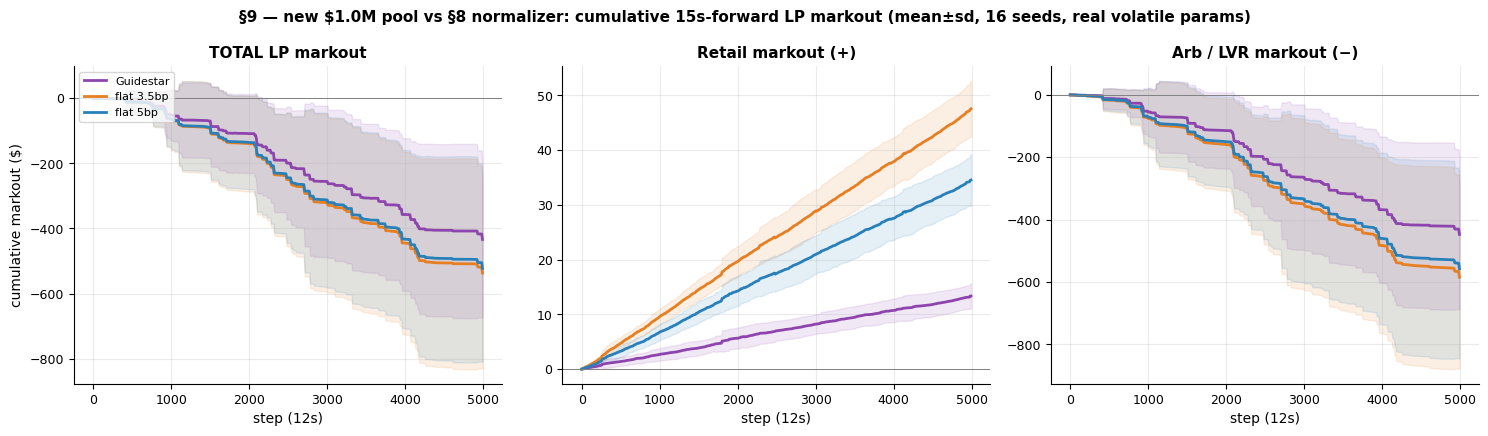

In [47]:
fig = plot_gs_cumulative()
plt.show()

**Per-trade 15s markout (bps) distribution** (&#36;1M pool, pooled over seeds). The three distributions largely overlap; the body is concentrated within a few bps of 0.

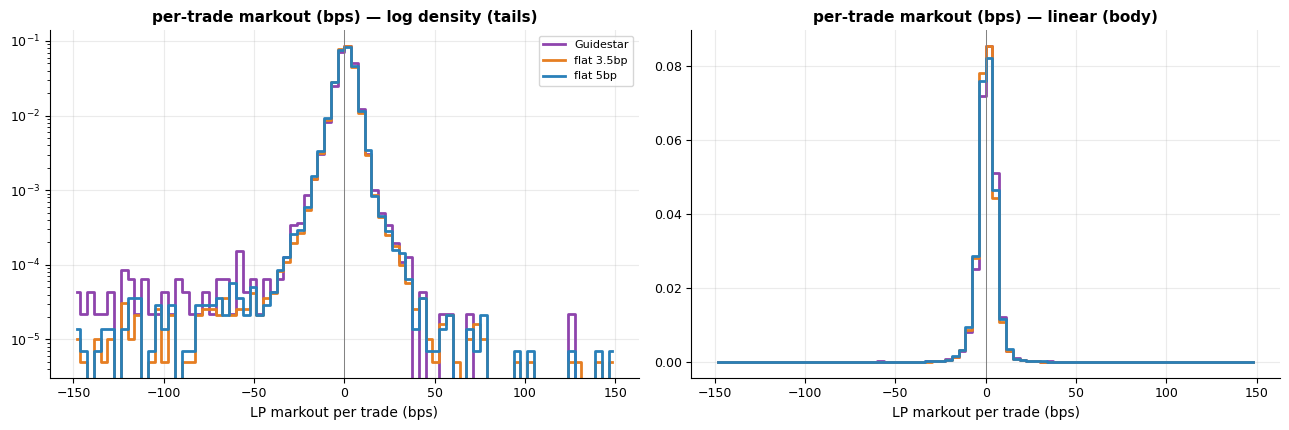

In [48]:
fig = plot_gs_histograms()
plt.show()

**Markout by captured trade size** (&#36;1M pool; x = captured notional per trade). **Left** — retail LP markout (bps) per size bin as the **median with IQR band** (solid), with the per-bin **mean** overlaid (dotted); bins with fewer than 30 retail trades are not drawn. Median markout sits near the fee (≈2.5–3.5 bps) up to ~&#36;300 captured and rises in the &#36;0.3k–1k bins. **Centre** — summed markout (&#36;) over all trades is ≈0 below ~&#36;1k and deepens monotonically with size to a minimum (≈ −&#36;310 to −&#36;380) in the largest **populated** bin (≈&#36;7k–15k), where the line ends — bins above ~&#36;31k hold **no captured trades** at this depth and are left blank (plotting them as 0 would read as 'profitable' when it is really 'no data'). **Right** — captured volume (&#36;) by size: flat 3.5 bps captures the most across the retail-size range and Guidestar the least; the three converge in the largest buckets.

Two features looked unusual and are diagnosed in the next cell. (i) The left panel's earlier **mean** version spiked to 10–16 bps in the &#36;0.7k–3k bins and then ended abruptly — the **sparse tail** of the size distribution (retail count per captured-size bin falls from ~2,200 at &#36;147 to 52 / 7 / 1 at &#36;681 / &#36;1.5k / &#36;3k). The median+IQR view gates these out. (ii) The centre panel is a *sum* over trades, so its shape is a count×size effect: it is **arb/LVR** (not retail), it deepens with size because larger arb trades carry more LVR, and it simply stops where trades run out — it is **not** that &#36;10⁵ trades are profitable, there are none.

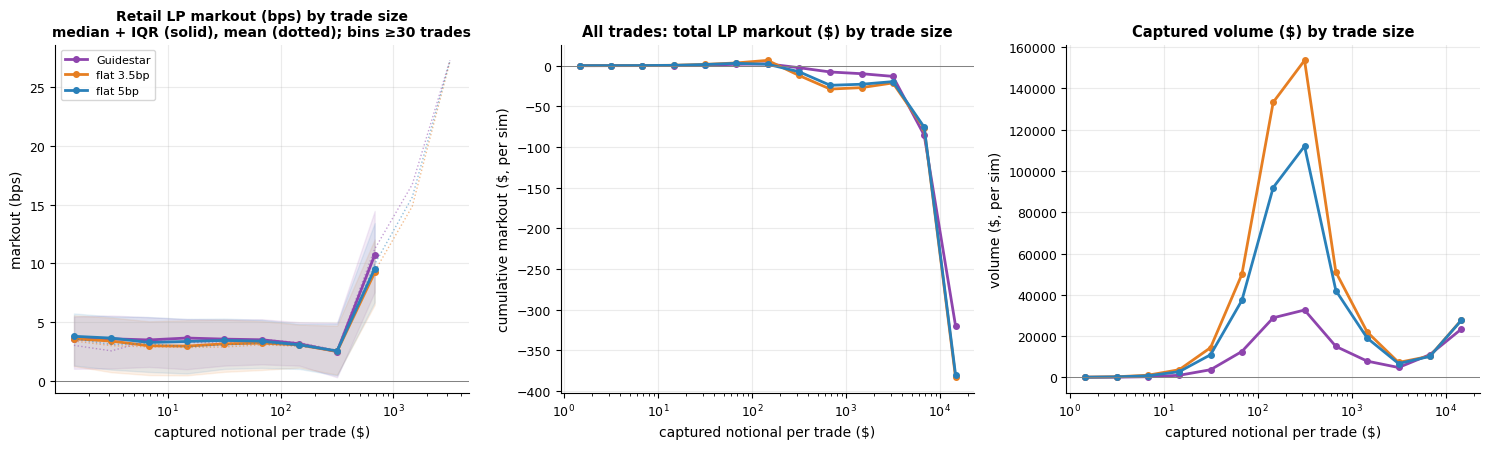

In [49]:
fig = plot_gs_by_size()
plt.show()

**By-size diagnostics.** Is the left-panel rise a single outlier, and is the centre-panel spike an artifact?

- **(A)** Per bin the retail markout **mean ≈ median ≈ leave-one-out mean** (dropping the single most extreme trade), so the rise is *not* a single removable outlier. **(B)** But the retail **count** per captured-size bin falls below 30 above ~&#36;1k (52 → 7 → 1 trade), so the magnitude and the abrupt end of the curve are sparse-tail estimates; the chart above gates at ≥30 trades.
- **(C)** The centre-panel total-&#36; minimum at ≈&#36;7k–15k is composed **entirely of arb trades** (the arb-only line coincides with the total). **(D)** The largest single trade contributes only ~5% of that bin's total |markout| and the top-5 ~20% (across ~40 arb trades), so it is **not** outlier-driven. It is the shallow pool's LVR, concentrated in the captured-size band of the arb trades that realign a &#36;1M pool after a fair-price move, and the line ends at the largest populated bin (~&#36;15k): bins above ~&#36;31k hold no captured trades at this depth, so the total there is 0 only because it is **empty**, not profitable.

Both features are properties of the size distribution and the arb/LVR size band, not single-trade artifacts.

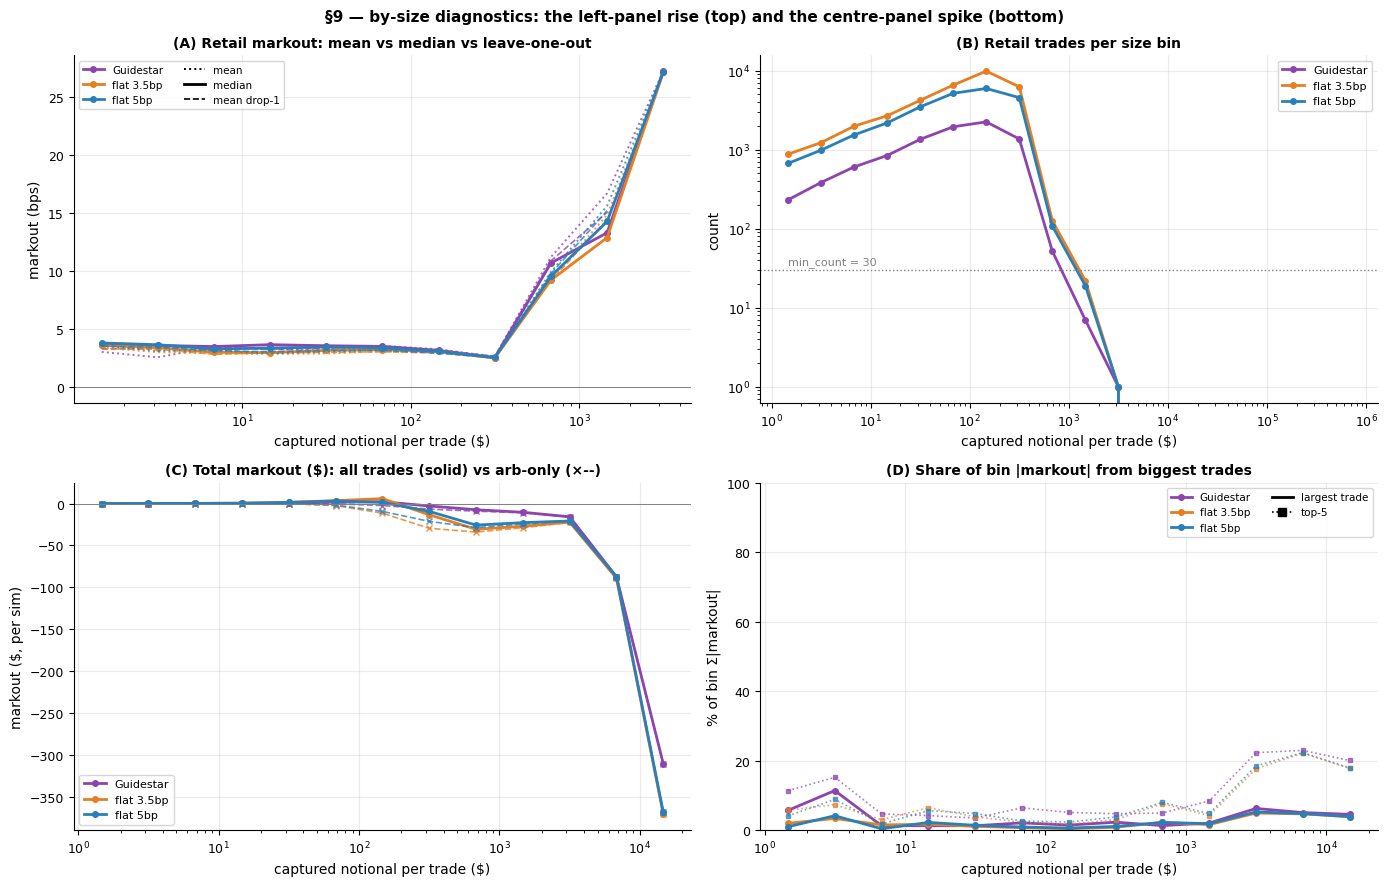

In [50]:
fig = plot_gs_by_size_diag()

**Final cumulative markout vs retail arrival multiplier** (&#36;1M pool, 8 seeds), scaling retail arrival from 1× to 16× the calibrated rate. At 1×: Guidestar −443, flat 5 bps −538, flat 3.5 bps −554. As the multiplier increases, the flat 3.5 bps curve has the steepest slope and crosses &#36;0 near 13×; the flat 5 bps curve stays below &#36;0 through 16×; the Guidestar curve has the smallest slope (−443 → −345). The flat-3.5 bps and Guidestar curves cross near 4×.

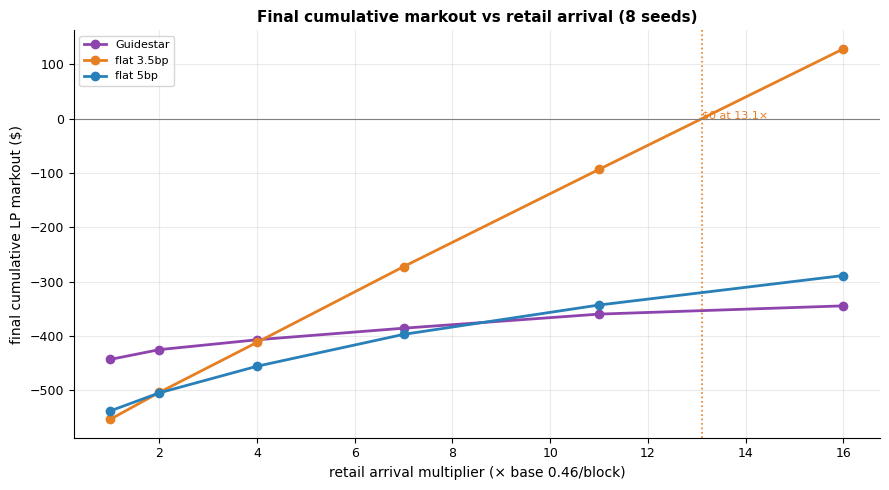

In [51]:
fig = plot_gs_breakeven()
plt.show()

**Retail volume captured** (&#36; per sim), by pool and depth. &#36;1M: Guidestar &#36;38k, flat 5 bps &#36;109k, flat 3.5 bps &#36;156k. &#36;0.5M: &#36;20k / &#36;60k / &#36;86k.

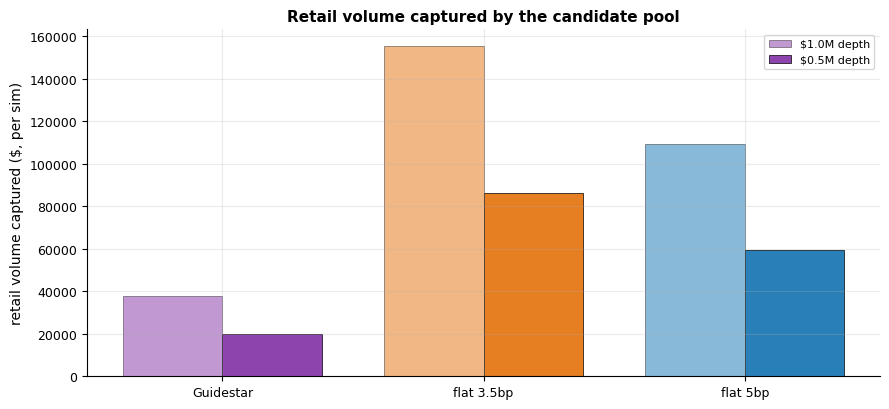

In [52]:
fig = plot_gs_volume()
plt.show()

---
## Section 10: Sensitivity to retail arrival rate and size distribution

The breakeven chart (§9) showed the three pools have **different sensitivity to retail arrival rate**: the flat low-fee curves rise much faster than Guidestar as orders arrive more often. This section decomposes that, then asks the analogous question for the retail **size distribution** (mean and spread). All at the &#36;1M depth, 24 paired seeds.

### Chart 10a: Why arrival rate favours the low-fee pools — markout decomposition

Final LP markout split into its **retail (+)** and **arb/LVR (−)** components, plus retail volume captured, across the arrival multiplier (1×→16× the calibrated rate).

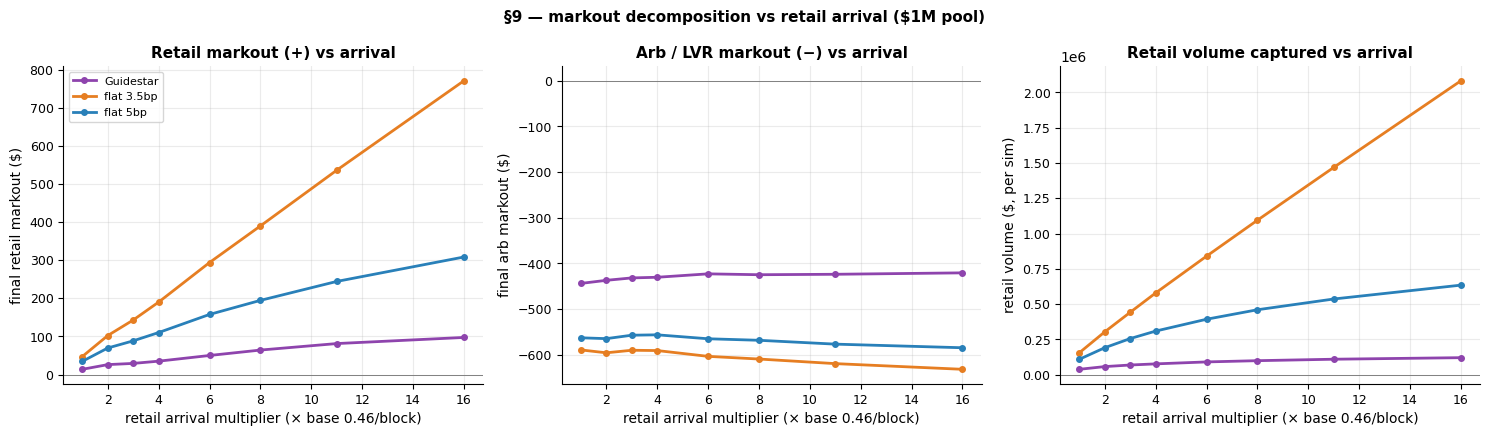

In [53]:
fig = plot_gs_arrival_decomp()

**What the chart shows:**
- The **retail (+)** component rises with arrival for all three, at very different rates: Guidestar +14→+97, flat 5 bps +35→+308, flat 3.5 bps +47→+771.
- The **arb/LVR (−)** component is approximately flat in arrival rate: Guidestar −444→−421, flat 5 bps −563→−585, flat 3.5 bps −590→−632.
- So the total's improvement with arrival is almost entirely the retail component; the arb/LVR loss does not scale with how often retail arrives.

**Mechanism** (consistent with the routing code and the captured-volume figures; offered as the explanation, not an additional measurement). The router splits each order to equalize marginal price, giving the submission pool a share that scales with √((1−fee)·x·y) — so a higher submission fee routes a smaller share to it (numerically, a &#36;50k buy sends 0.48% / 0.33% / ~0% of itself to the submission pool at 3.5 / 5 / ≥30 bps). Captured retail volume reflects this ordering: &#36;156k (flat 3.5) > &#36;109k (flat 5) > &#36;38k (Guidestar). Retail flow is net profitable to the LP, and that profit scales with captured volume, so more frequent arrivals lift the cheap pools fastest. Guidestar's edge is on the arb/LVR side (its directional fee defends the back-run side after a move); that loss is set by the fair-price path, not the arrival rate, so it is fixed in size and does not grow with more retail. Net: the *scalable* advantage (benign-retail capture) belongs to the low-fee pools; Guidestar's advantage (arb defense) does not scale with arrival rate, so frequent arrivals erode its relative standing.

### Chart 10b: Sensitivity to the retail size distribution (mean and spread)

The size distribution is sampled from the calibrated empirical quantiles (median ≈ &#36;276, mean ≈ &#36;2.3k, log10-spread ≈ 1.0). Two counterfactuals: **mean shift** multiplies every order size by m (mean and spread move together); **spread shift** applies a log-spread around the *fixed median*, size′ = median·(size/median)^s, with sizes **capped at the empirical max (&#36;1.36M)** so widening cannot invent orders larger than any observed in the 90-day window. Dashed grey vertical = the calibrated distribution; dotted verticals = &#36;0 crossings.

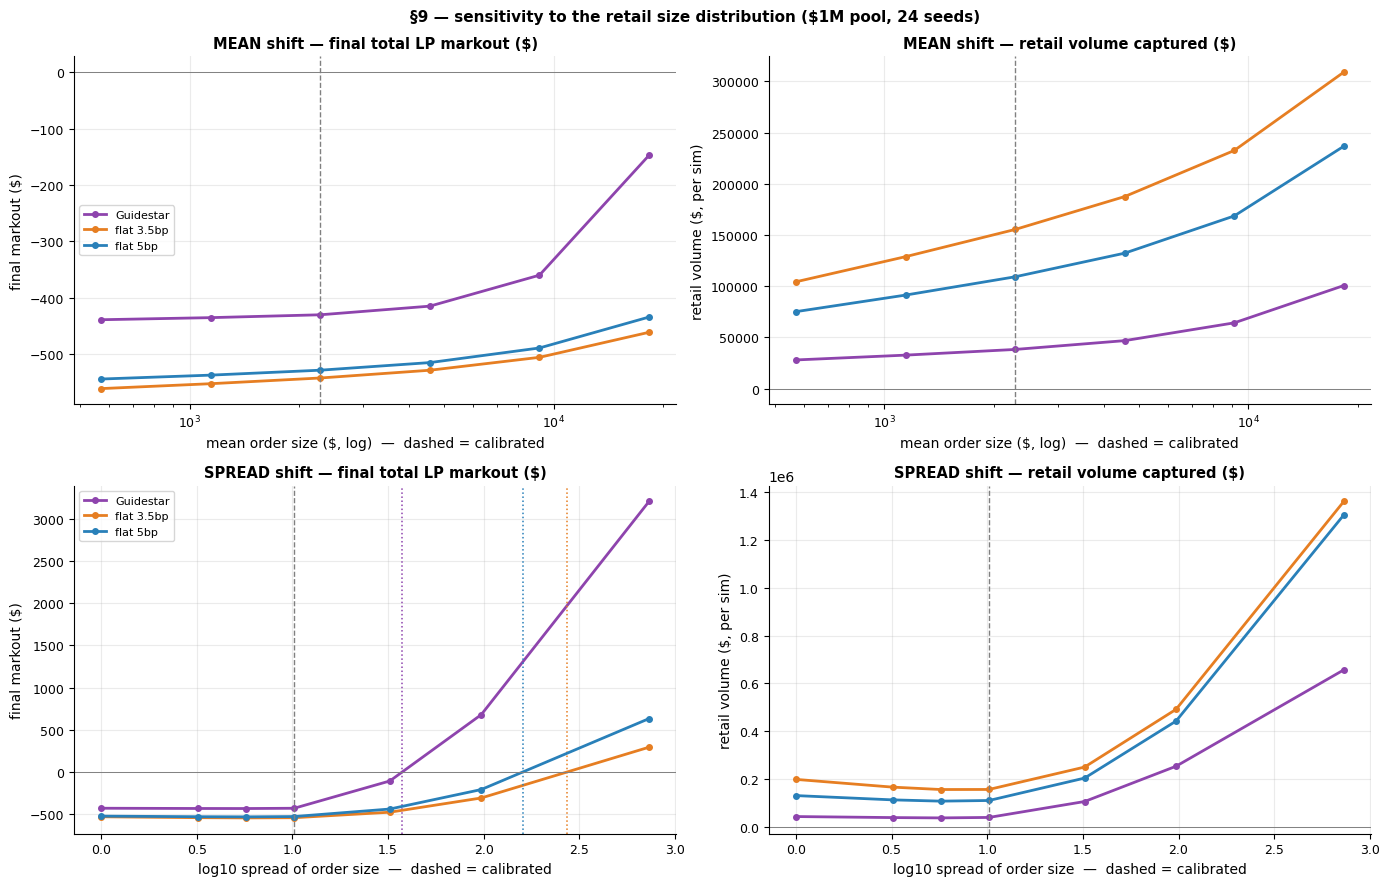

In [54]:
fig = plot_gs_sizedist()

**What the charts show:**
- **Mean shift** (top): as the mean order size rises, every pool's final markout becomes less negative, and **Guidestar improves the most** (−430 → −147 at mean ≈&#36;18k, vs flat 5 bps −529 → −434 and flat 3.5 bps −542 → −461). Captured volume rises for all, Guidestar lowest throughout.
- **Spread shift** (bottom): below the calibrated spread the three are ≈flat; above it every pool improves and **Guidestar improves fastest, crossing &#36;0 first** (≈ spread 1.5, vs the flats near 2–2.9). Captured volume rises steeply with spread for all.
- **Direction vs arrival.** A larger or more-dispersed size distribution (more mass in large orders) **widens Guidestar's lead**; a higher arrival rate **narrows and reverses it**. The two sensitivities have opposite sign.

**Mechanism (hypothesis, to test separately).** Both 'bigger mean' and 'wider spread' put more notional into large orders, which carry the most price impact / adverse selection — exactly what Guidestar's directional, size-aware fee charges for — so its relative position improves as orders get larger. Arrival rate instead adds more small, benign orders, the largest share of which the cheapest pool captures.

---
## Section 11: Unifying the two regimes — can one adaptive fee do both?

§10 showed the two sensitivities have **opposite sign**: more frequent retail favours a low flat fee, while larger / more-dispersed orders favour Guidestar's defense. This section asks whether a single adaptive policy can win in both regimes. All results at the &#36;1M depth, 12 paired seeds; new strategies live in `arena_eval/exact_simple_amm/flow_aware_guidestar.py`.

### Chart 11a: the intuition

Two flow channels act on the LP: benign **retail** (earns spread; the captured share rises as the fee falls, and the dollar profit scales with arrival rate) and toxic **arb / LVR** (loses; scales with volatility × order size; mitigated by a directional fee). The regime is set by where in the (arrival, size) plane the flow sits.

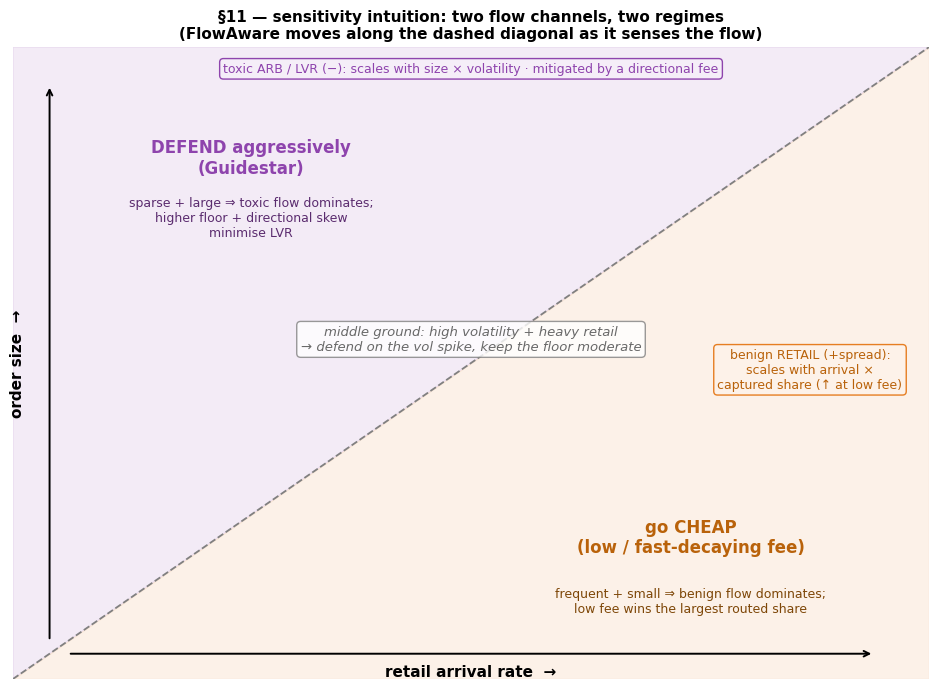

In [55]:
fig = plot_gs_intuition_schematic()

### Chart 11b: arrival × size regime map

For each cell of an arrival-multiplier × size-multiplier grid, the final 15s LP markout of each static pool (&#36;1M, 12 seeds). **Left** — which static pool wins. **Right** — Guidestar minus the best flat (&#36;), with the &#36;0 boundary.

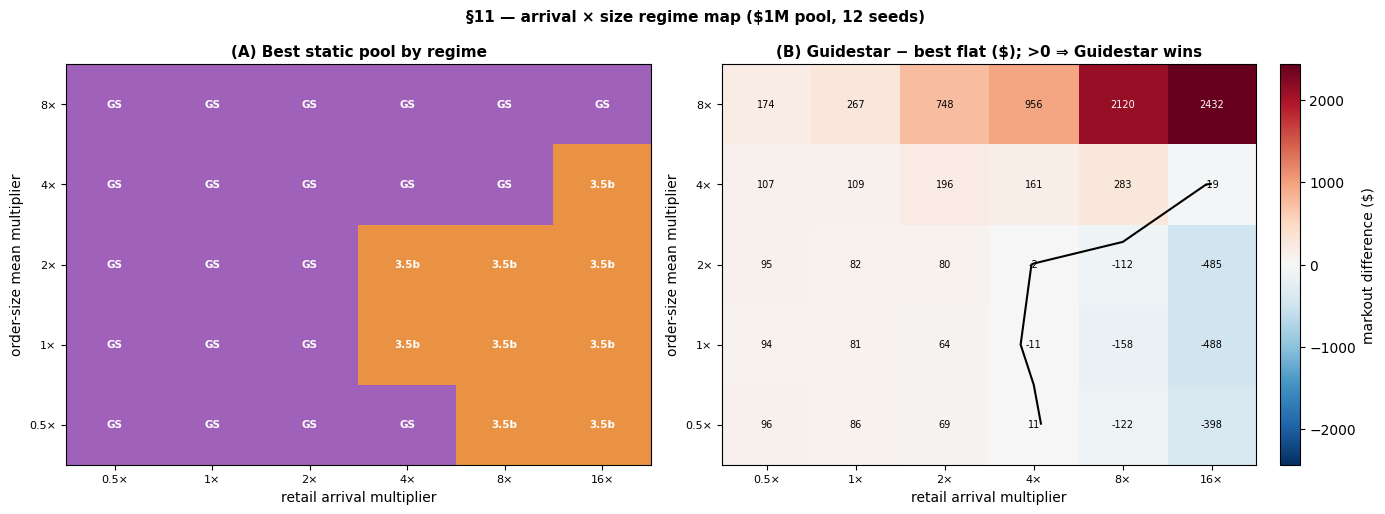

In [56]:
fig = plot_gs_regime_map()

**What the map shows.** Guidestar has the best static markout across most of the plane — all of the low/moderate-arrival columns and every large-size cell. A flat 3.5 bps pool wins only the **high-arrival × small/mid-size** corner (lower-right), where benign retail dominates and the cheaper fee captures the larger routed share. The &#36;0 boundary runs diagonally: defense wins up-and-left, cheap wins down-and-right — the §10 sensitivities, made spatial.

### Three candidate unifying strategies

`before_swap` sees the incoming order size, so a hook can react to it. Three controllers — each keeps Guidestar's volatility machinery underneath and blends its quote with a quiet flat floor by a weight `d`:
- **FlowAware** — `d` from a lagged per-block EWMA of arrival count & size (the literal "detect the regime" version).
- **SizeAware** — `d` from the **current order's size** (small ⇒ cheap, large ⇒ defend; the arb leg always defended).
- **Unified** — SizeAware's per-order retail rule **plus** a flow-gated arb defense (defend the arb only when retail is sparse).

Each is scored against the **best static pool in that cell** — the envelope a unifier would need to track.

KeyError: 'Unified'

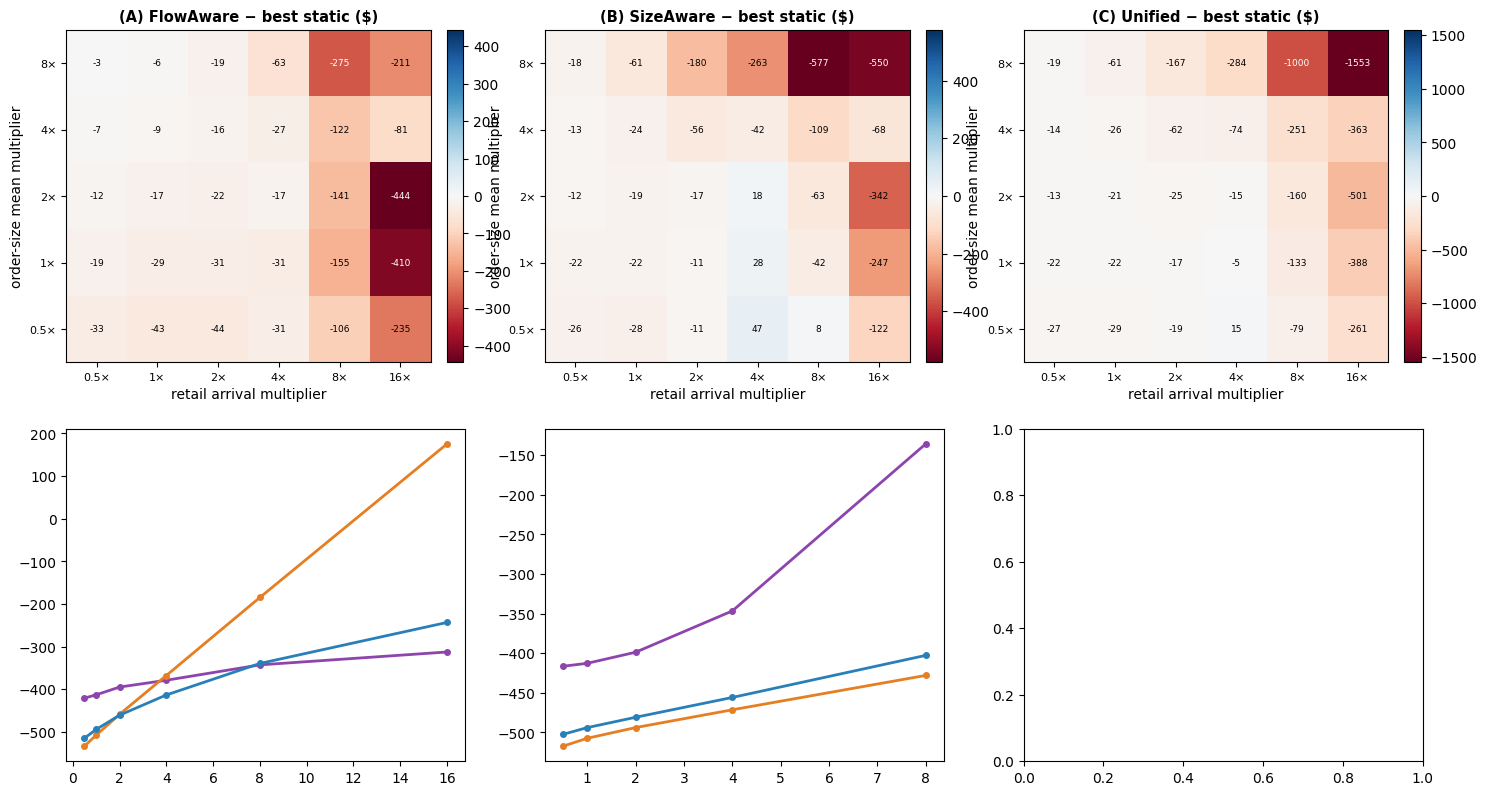

In [57]:
fig = plot_gs_adaptive()

**What the comparison shows.** None of the three tracks the best-static envelope. Counting cells where each ties or beats the best static (within &#36;1, of 30): **FlowAware 0, SizeAware 4, Unified 1**. SizeAware is the only one that *beats* the best static anywhere — a band at arrival ×4, small/mid size (e.g. +&#36;47 at mean ×0.5, arrival ×4) — and it lags elsewhere.

The failures are informative — each a distinct coupling:
1. **FlowAware** lags everywhere: the block-level blend still applies a fraction of the directional spike on every volatile block, and in the busy regime that fraction leaks onto the abundant retail.
2. **SizeAware** quotes small retail cheaply but defends the arb. The decomposition (regime cache) shows that in the busy corner this **cuts the arb loss yet collapses retail markout** — at mean ×0.5, arrival ×16: arb −&#36;258 vs the flat pool's −&#36;549, but retail +&#36;168 vs +&#36;581. The arb also **realigns the pool to fair**, a public good for the heavy retail; starving it costs more than the LVR it saves.
3. **Unified** gates the arb defense on busyness, which backfires in the **large-order + high-arrival** corner (mean ×8, arrival ×8: &#36;1586 vs Guidestar's &#36;2586): there the arb still carries large LVR and should be defended *despite* the high arrival.

**Reading.** The optimal fee is a non-separable function of (arrival, size, volatility), and the arb leg's dual role — LVR extraction vs pool realignment — couples the retail and arb P&L. So a simple reactive single-fee rule does not dominate per-regime static tuning here. Guidestar is a strong default (best across most of the map); the one regime it loses is high-arrival / small-size. Capturing that corner without sacrificing defense elsewhere would likely need a **hard switch** (to avoid spike leakage) and **joint (size × arrival) regime identification**, not a one- or two-signal blend — the indicated next step rather than a finished result.

---
## Section 12: The Nezlobin / Volatile-Hook strategy

A directional intra-block fee (Alex Nezlobin's mainnet Volatile-Hook spec). With `P_TOB` the
block-open mid and `P_BS` the pre-swap mid, the **reverting** side is surcharged by
`½·(P_BS−P_TOB)/P_BS` and the **continuation** side by `max(α·move, d)`; resting fees sum to
`TS = 9 bps`, skewed by an EMA of per-block price impact, with a big-PI spread-widening
exception. Implemented in `arena_eval/exact_simple_amm/nezlobin_dynamic_fee.py`.

It is run in the **bottom-of-block-arb environment**: a same-block backrun realigns the pool to
fair after retail (the leg that pays the surcharge; `arb_max_passes=3`), against the §8
full-market normalizer. Every pool shares this env on paired seeds — only the fee policy differs
— so the flat baselines also get the same-block backrun (their numbers therefore differ from §9,
which had no bottom arb).

### Chart 12a: fee mechanics

Driving the strategy through a scripted multi-block path. **(A)** price; **(B)** quoted bid/ask
over swaps — resting level + intra-block surcharge spikes; **(C)** resting fees per block — the
EMA-of-PI skew and the big-PI exception (the sum exceeds TS at the big-move block, then is
bypassed); **(D)** the surcharge transfer function — reverting side `½·move`, continuation side
`max(α·move, d)`.

In [ ]:
fig = plot_nezlobin_dynamics()

### Chart 12b: outcome by liquidity depth (&#36;0.5M–&#36;5M)

Final 15s-forward LP markout vs depth, the cumulative path at &#36;1M, retail volume captured, the
per-trade markout distribution, and markout by captured trade size.

In [ ]:
fig = plot_nz_depth_sweep()

In [ ]:
fig = plot_nz_cumulative()

In [ ]:
fig = plot_nz_volume()

In [ ]:
fig = plot_nz_histograms()

In [ ]:
fig = plot_nz_by_size()

**What the depth sweep shows.** At the calibrated arrival rate, total LP markout is negative
for all pools and scales ~linearly more negative with depth. **Guidestar is least-negative at every
depth; Nezlobin ≈ flat 4.5/4.5 ≈ flat 5 bps** (the three cluster). The decomposition is that
Guidestar's entire edge is a smaller arb/LVR loss; on retail the four are similar. Nezlobin captures
less retail volume than the flats (its reverting-side surcharge pushes some flow to the normalizer)
but more than Guidestar.

### Chart 12c: why Guidestar out-marks Nezlobin at base arrival

In [ ]:
fig = plot_nz_intuition()

**(A)** Guidestar's only advantage is a **smaller arb/LVR loss** (≈ −&#36;447 vs Nezlobin
−&#36;562 at &#36;1M); retail is similar. **(B)** the mechanism, empirically: Guidestar is arbed
**~3.5× less often** (401 vs ~1,400 trades/sim) and each arb pays **~3.3× more** (≈23 vs ≈7 bps
effective) — it both *deters* and *taxes* the arb. Nezlobin's arb count/cost ≈ the flats', because
its surcharge lands on the **reverting** side, while the LVR-extracting **top-of-block arb is the
block's first swap and pays the resting fee — untaxed**. So Nezlobin does not defend the inter-block
LVR, which is the dominant cost here. **(C)** the trade-off: Guidestar captures the least retail
volume, yet its arb defense wins on net at base arrival.

### Chart 12d: sensitivity to arrival rate, size, and volatility

In [ ]:
fig = plot_nz_sensitivity()

**Sensitivity.** **Guidestar dominates the LVR-heavy regimes** — low arrival, large order
size, and high volatility — and its lead *grows* with size and volatility. **A cheap flat fee
(4.5/4.5) wins at high arrival** (benign-retail-dominated; it crosses above Guidestar past ~4–8×).
**Nezlobin tracks the flats throughout** — marginally better than them at large size (its surcharge
captures some same-block backrun) but never the best: it neither matches Guidestar's LVR defense nor
undercuts the cheap flat.

**Takeaway (this calibration).** The doc-aligned Nezlobin fee, as specified, does not out-mark either
incumbent in these regimes. Guidestar's persistent directional defense captures more of the dominant
**inter-block arb/LVR** cost (the part Nezlobin leaves untaxed on the top-of-block arb), and a flat
low fee captures more benign retail. Nezlobin's intra-block surcharge would matter most where
**same-block backruns** are the dominant cost — which this WETH/USDC calibration is not.